In [70]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import camelot

In [39]:
pip install camelot-py[cv]

Note: you may need to restart the kernel to use updated packages.


## 1. Data Extraction from CDSCO NSQ Alerts

### The CDSCO publishes monthly Not of Standard Quality (NSQ) alerts as PDF reports. These reports contain information regarding failed pharmaceutical ### products, manufacturers, batch details, and reasons for quality failure.

### In this section, tables are extracted from the PDF reports using Camelot and converted into structured data suitable for further analysis.


In [40]:
tables=camelot.read_pdf(
    "CDSCO NSQ june25.pdf",
    pages="all",
)

In [41]:
tables[0].df.head()

,0,1,2,3,4,5,6,7
0,S.No,Product/Drug Name,Batch No.,Manufact\nuring \nDate,Expiry \nDate,Manufactured By,NSQ Result,Reported by \nCDSCO \nLaboratory
1,1.,Dextrose Injection I.P. \n5%w/v (D5),1-3098,01/2025,12/2027,"M/s. Tam-Bran \nPharmaceuticals Pvt. Ltd., Plo...",Assay of Dextrose \n(Anhydrous),"CDL, Kolkata"
2,2.,Dexamethasone Sodium \nPhosphate Injection I.P...,P24L220,12/2024,11/2026,M/s. Paksons pharmaceuticals \nPrivate Limited...,"Free \nDexamethasone, \nParticulate matter \na...","CDL, Kolkata"
3,3.,Methylcobalamin Injection,S4H046,08/2024,01/2026,"M/s. Arion Healthcare, Vill. \nKishanpura, Bad...","Assay of \nMethylcobalamin, \nParticulate matt...","CDL, Kolkata"
4,4.,Tranexamic Acid Injection \nIP 500 mg/5ml,Z24-185,02/2024,01/2026,"M/s. Zee Laboratories Ltd., \nBehind 47, Indus...",Related \nSubstances and \nAssay of \nTranexam...,"CDL, Kolkata"


## Observation

### The extraction process successfully converted the PDF tables into structured DataFrames. Initial inspection confirmed the presence of key variables including product name, manufacturer, batch number, and NSQ failure reason.

### The extracted data still contains formatting inconsistencies such as line breaks and repeated headers that require cleaning before analysis.


In [42]:
print(len(tables))

6


In [43]:
all_tables=[]
for table in tables:
    all_tables.append(table.df)

In [44]:
june_df=pd.concat(
    all_tables,
    ignore_index=True
)
print(june_df.shape)

(58, 8)


In [45]:
june_df=june_df.replace(
    r'\n',
    ' ',
    regex=True
)

In [206]:
june_df.head()

,S.No,Product/Drug Name,Batch No.,Manufacturing Date,Expiry Date,Manufactured By,NSQ Result,Reported by CDSCO Laboratory
1,1.,Dextrose Injection I.P. 5%w/v (D5),1-3098,01/2025,12/2027,"M/s. Tam-Bran Pharmaceuticals Pvt. Ltd., Plot...",Assay of Dextrose (Anhydrous),"CDL, Kolkata"
2,2.,Dexamethasone Sodium Phosphate Injection I.P....,P24L220,12/2024,11/2026,"M/s. Paksons pharmaceuticals Private Limited,...","Free Dexamethasone, Particulate matter and ...","CDL, Kolkata"
3,3.,Methylcobalamin Injection,S4H046,08/2024,01/2026,"M/s. Arion Healthcare, Vill. Kishanpura, Badd...","Assay of Methylcobalamin, Particulate matter...","CDL, Kolkata"
4,4.,Tranexamic Acid Injection IP 500 mg/5ml,Z24-185,02/2024,01/2026,"M/s. Zee Laboratories Ltd., Behind 47, Indust...",Related Substances and Assay of Tranexamic ...,"CDL, Kolkata"
5,5.,Oxytocin Injection I.P. 1ml,AOX-2402,04/2024,03/2026,"M/s. Systochem Laboratories Ltd., B-75 Roop N...",Assay of Oxytocin,"CDL, Kolkata"


In [47]:
june_df.columns=june_df.iloc[0]
june_df=june_df[1:]

In [189]:
june_df.head()

,S.No,Product/Drug Name,Batch No.,Manufacturing Date,Expiry Date,Manufactured By,NSQ Result,Reported by CDSCO Laboratory
1,1.,Dextrose Injection I.P. 5%w/v (D5),1-3098,01/2025,12/2027,"M/s. Tam-Bran Pharmaceuticals Pvt. Ltd., Plot...",Assay of Dextrose (Anhydrous),"CDL, Kolkata"
2,2.,Dexamethasone Sodium Phosphate Injection I.P....,P24L220,12/2024,11/2026,"M/s. Paksons pharmaceuticals Private Limited,...","Free Dexamethasone, Particulate matter and ...","CDL, Kolkata"
3,3.,Methylcobalamin Injection,S4H046,08/2024,01/2026,"M/s. Arion Healthcare, Vill. Kishanpura, Badd...","Assay of Methylcobalamin, Particulate matter...","CDL, Kolkata"
4,4.,Tranexamic Acid Injection IP 500 mg/5ml,Z24-185,02/2024,01/2026,"M/s. Zee Laboratories Ltd., Behind 47, Indust...",Related Substances and Assay of Tranexamic ...,"CDL, Kolkata"
5,5.,Oxytocin Injection I.P. 1ml,AOX-2402,04/2024,03/2026,"M/s. Systochem Laboratories Ltd., B-75 Roop N...",Assay of Oxytocin,"CDL, Kolkata"


### Observation

### The cleaning process removed formatting artifacts and standardized column names across monthly reports. The resulting dataset provides a consistent structure for subsequent analysis and visualization.

In [55]:
june_df.to_csv(
    "june_clean.csv",
    index=False
)

In [50]:
df=pd.read_csv(
    "june_clean.csv"
)

In [56]:
print(df.columns)

Index(['S.No', 'Product/Drug Name', 'Batch No.', 'Manufact uring  Date',
       'Expiry  Date', 'Manufactured By', 'NSQ Result',
       'Reported by  CDSCO  Laboratory'],
      dtype='object')


In [24]:
march_tables=camelot.read_pdf(
    "NSQ Alert For The Month of March-2025.pdf",
    pages="all"
)

In [25]:
all_tables_march=[]
for table in march_tables:
    all_tables_march.append(table.df)
march_df=pd.concat(
    all_tables_march,
    ignore_index=True
)

In [26]:
march_df = march_df.replace(
    r'\n',
    ' ',
    regex=True
)

In [27]:
march_df.columns = march_df.iloc[0]
march_df = march_df[1:]

In [84]:
march_df.to_csv(
    "march_clean.csv",
    index=False
)

In [85]:
print(june_df.columns)
print(march_df.columns)

Index(['S.No', 'Product/Drug Name', 'Batch No.', 'Manufacturing  Date',
       'Expiry  Date', 'Manufactured By', 'NSQ Result',
       'Reported by  CDSCO  Laboratory'],
      dtype='object', name=0)
Index(['S.No', 'Product/Drug Name', 'Batch No.', 'Manufacturing  Date',
       'Expiry  Date', 'Manufactured By', 'NSQ Result',
       'Reported by  CDSCO  Laboratory'],
      dtype='object', name=0)


## 3. Dataset Integration

### Individual monthly NSQ reports were merged into a single master dataset. Combining multiple months allows broader trend analysis and improves the robustness of observations regarding pharmaceutical quality failures.

In [86]:
master_df = pd.concat(
    [march_df, june_df],
    ignore_index=True
)

In [87]:
master_df.shape

(131, 8)

In [88]:
master_df.to_csv(
    "master_nsq.csv",
    index=False
)

In [89]:
master_df["NSQ Result"].value_counts().head(20)

NSQ Result
Particulate Matter  and Description                               10
Dissolution (for  Calcium)                                         8
Dissolution                                                        6
Loss on drying                                                     5
Sterility                                                          4
Assay/content of  Cholecalciferol  (Vitamin D3)                    4
                                                                   4
Dissolution of  Telmisartan                                        4
Description                                                        3
"Related  substances"                                              2
Sterility of Water  for Injection                                  2
Dissolution  (Buffer Stage)                                        2
Assay of  Rabeprazole  Sodium                                      2
Water                                                              2
Dissolution of  Pantopr

## 4. Failure Category Engineering

### The raw NSQ failure descriptions contain highly specific laboratory observations. To facilitate analysis, individual failure reasons were grouped into broader categories such as Dissolution, Assay, Sterility, and Particulate Matter.

### This transformation enables meaningful comparison of failure patterns across different drug classes and dosage forms.

In [129]:
def categorize_failure(text):

    text = str(text).lower()

    if "dissolution" in text:
        return "Dissolution"

    elif "assay" in text:
        return "Assay"

    elif "sterility" in text:
        return "Sterility"

    elif "particulate" in text:
        return "Particulate Matter"

    elif "microbial" in text:
        return "Microbial"

    elif "related substance" in text:
        return "Related Substances"

    elif "loss on drying" in text:
        return "Loss on Drying"

    elif "water" in text:
        return "Water Content"

    elif "ph" in text:
        return "pH"

    elif "description" in text:
        return "Description"

    else:
        return "Other"

In [130]:
master_df["Failure_Category"] = (
    master_df["NSQ Result"].apply(categorize_failure)
)

In [131]:
value_counts=master_df["Failure_Category"].value_counts()

## 5. Distribution of NSQ Failure Categories

### This analysis examines the frequency of various NSQ failure categories to identify the most common causes of pharmaceutical quality failures within the dataset.

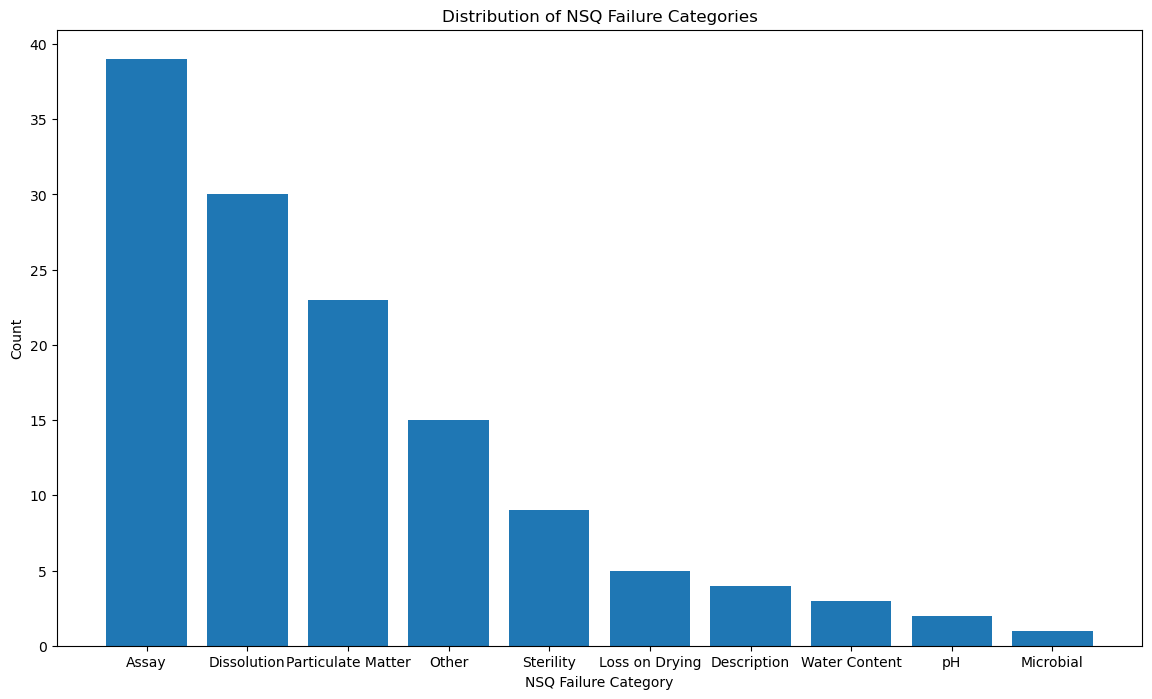

In [207]:
plt.figure(figsize=(14,8))
plt.bar(value_counts.index,value_counts.values)
plt.xlabel("NSQ Failure Category")
plt.ylabel("Count")
plt.title("Distribution of NSQ Failure Categories")
plt.show()

In [136]:
master_df["Product/Drug Name"].head(20)

0     Amoxicillin Sodium and  Clavulanate Potassium ...
1     Pantoprazole Gastro- Resistant Tablets IP  (Pa...
2                        Pantoprazole tablets IP  40 mg
3     Adrenaline Bitartrate  Injection IP (Reoline  ...
4     Bupivacaine  Hydrochloride In  Dextrose Inject...
5     Montelukast and  Levocetirizine Tablet  (Dumon...
6         Nitrazepam Tablets I.P.  10 mg. (Nitravet-10)
7     Vitamin B1, Vitamin B2,  Nicotinamide, Vitamin...
8     Vitamin B1, Vitamin B2,  Nicotinamide, Vitamin...
9      Calcium D-Pantothenate  Syrup (B-Complex  Syrup)
10    Vitamin C, Vitamin B12,  Folic Acid and  Niaci...
11    Ceftriaxone and  Salbactam for Injection  1.5 ...
12    Ceftriaxone &  Sulbactam for Injection  IP (Ce...
13    Pantoprazole Gastro- Resistant and  Domperidon...
14    Chlorhexidine Gluconate  & Ethyle Alcohol Baed...
15    Dexamethasone Sodium  Phosphate Injection IP  ...
16        Itraconazole Capsules  BP 100 mg (Fungis-100)
17     Gentamicin Sulphate  Injection IP  (GENTA

## 6. Medicine type Classification

### Drug products were classified according to medicine types (Tablet, Capsule, Injection, Syrup, etc.). Medicine type is an important attribute because different quality issues tend to be associated with different formulation types.

In [158]:
def medicine_type(product):

    product = str(product).lower()

    if "tablet" in product:
        return "Tablet"

    elif "capsule" in product:
        return "Capsule"

    elif "injection" in product:
        return "Injection"

    elif "syrup" in product:
        return "Syrup"

    elif "suspension" in product:
        return "Suspension"

    elif "cream" in product:
        return "Cream"

    elif "ointment" in product:
        return "Ointment"

    elif "gel" in product:
        return "Gel"

    elif "drops" in product:
        return "Drops"

    elif "powder" in product:
        return "Powder"

    else:
        return "Other"

In [159]:
master_df["Medicine_type"] = (
    master_df["Product/Drug Name"].apply(medicine_type)
)

In [160]:
Value_Count=master_df["Medicine_type"].value_counts()

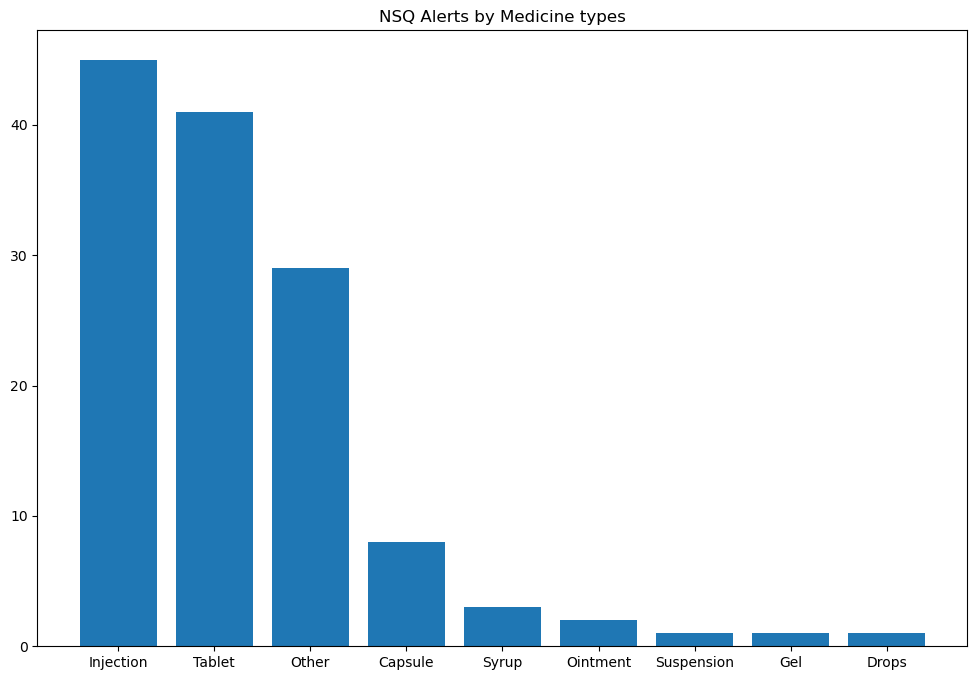

In [208]:
plt.figure(figsize=(12,8))
plt.bar(Value_Count.index,Value_Count.values)
plt.title("NSQ Alerts by Medicine types")
plt.show()

In [162]:
cross=pd.crosstab(
    master_df["Medicine_type"],
    master_df["Failure_Category"]
)
cross

Failure_Category,Assay,Description,Dissolution,Loss on Drying,Microbial,Other,Particulate Matter,Sterility,Water Content,pH
Medicine_type,,,,,,,,,,
Capsule,4,0,4,0,0,0,0,0,0,0
Drops,1,0,0,0,0,0,0,0,0,0
Gel,0,0,0,0,0,1,0,0,0,0
Injection,13,0,0,0,0,3,20,6,1,2
Ointment,2,0,0,0,0,0,0,0,0,0
Other,8,0,0,5,0,8,3,3,2,0
Suspension,1,0,0,0,0,0,0,0,0,0
Syrup,2,0,0,0,1,0,0,0,0,0
Tablet,8,4,26,0,0,3,0,0,0,0


In [163]:
master_df[master_df["Failure_Category"]=="Dissolution"]["Product/Drug Name"].value_counts()

Product/Drug Name
Calcium Carbonate 500  mg + VIT. D3 250 IU  TABLETS IP (CALXIA  500 )                                           3
Telmisartan Tablets IP 40  mg                                                                                   3
Pantoprazole tablets IP  40 mg                                                                                  1
Montelukast and  Levocetirizine Tablet  (Dumont-L )                                                             1
Itraconazole Capsules  BP 100 mg (Fungis-100)                                                                   1
Pantoprazole Gastro- Resistant and  Domperidone  Prolonged-release  Capsules IP (Pantoryl- DSR )                1
Calcium& Vitamin D3  Tablets IP                                                                                 1
Cefuroxime Axetil  Tablets I.P. 500 mg  (BREXETIL-500 )                                                         1
Calcium Carbonate 500  mg + VIT.D3 250 IU  TABLETS IP (CALXIA- 500 )  

## 7. Therapeutic Drug Class Classification

### Products were grouped into therapeutic categories such as Proton Pump Inhibitors (PPIs), Antibiotics, Antihypertensives, Supplements, and Antifungals.

### This classification enables identification of quality-failure trends within specific therapeutic segments.

In [169]:
def drug_class(product):

    product = str(product).lower()

    if "pantoprazole" in product:
        return "PPI"

    elif "rabeprazole" in product:
        return "PPI"

    elif "telmisartan" in product:
        return "Antihypertensive"

    elif "azithromycin" in product:
        return "Antibiotic"

    elif "cefuroxime" in product:
        return "Antibiotic"

    elif "itraconazole" in product:
        return "Antifungal"

    elif "albendazole" in product:
        return "Anthelmintic"

    elif "alprazolam" in product:
        return "CNS"

    elif "vitamin d" in product or "calcium" in product:
        return "Supplement"

    else:
        return "Other"

In [170]:
master_df["Drug_Class"] = (
    master_df["Product/Drug Name"].apply(drug_class)
)


In [171]:
pd.crosstab(
    master_df["Drug_Class"],
    master_df["Failure_Category"]
)

Failure_Category,Assay,Description,Dissolution,Loss on Drying,Microbial,Other,Particulate Matter,Sterility,Water Content,pH
Drug_Class,,,,,,,,,,
Anthelmintic,0,0,1,0,0,0,0,0,0,0
Antibiotic,0,0,2,0,0,0,0,0,0,0
Antifungal,0,0,1,0,0,0,0,0,0,0
Antihypertensive,0,0,6,0,0,0,0,0,0,0
CNS,0,0,1,0,0,0,0,0,0,0
Other,28,4,2,5,0,15,21,8,3,2
PPI,5,0,7,0,0,0,0,1,0,0
Supplement,6,0,10,0,1,0,2,0,0,0


In [172]:
dissolution_df = master_df[master_df["Failure_Category"]=="Dissolution"]
dissolution_df["Drug_Class"].value_counts()

Drug_Class
Supplement          10
PPI                  7
Antihypertensive     6
Other                2
Antibiotic           2
Antifungal           1
CNS                  1
Anthelmintic         1
Name: count, dtype: int64

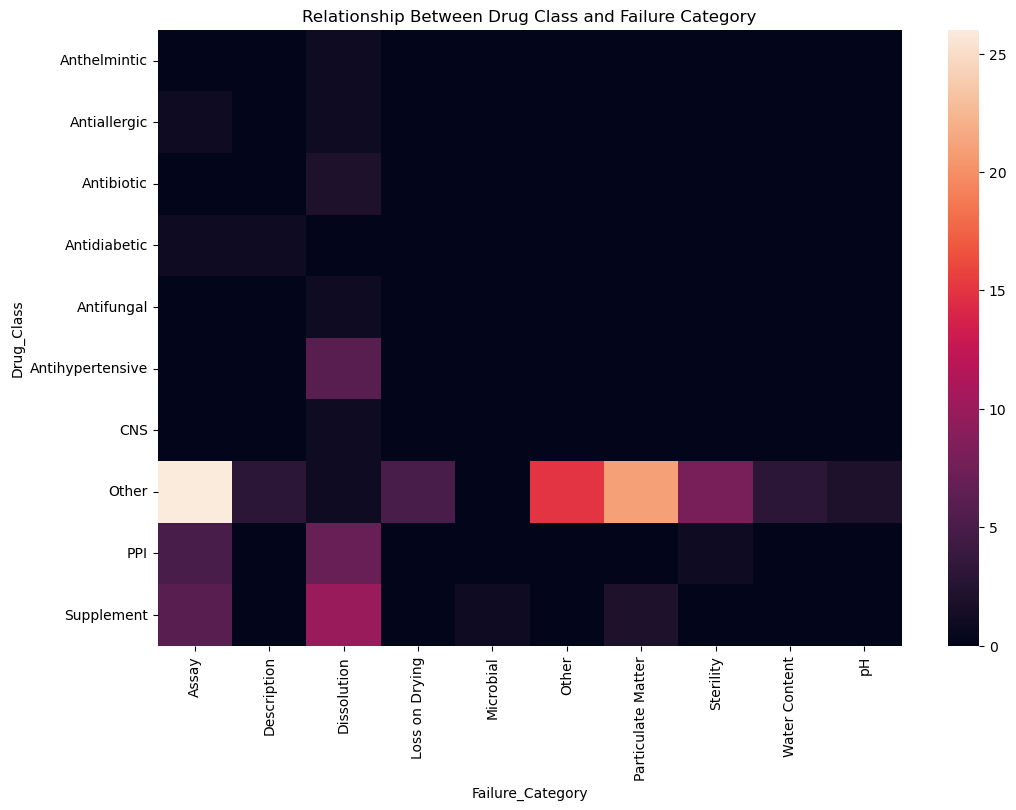

In [209]:
plt.figure(figsize=(12,8))
sns.heatmap(pd.crosstab(master_df["Drug_Class"],master_df["Failure_Category"]))
plt.title("Relationship Between Drug Class and Failure Category")
plt.show()

## 8. Investigation of Uncategorized Products

### To improve dataset quality, products assigned to the "Other" category were examined manually. Recurring therapeutic groups were identified and incorporated into the classification framework.

### This iterative process reduced information loss and increased the interpretability of downstream analyses.

In [174]:
(master_df["Medicine_type"]=="Other").mean()*100

np.float64(22.137404580152673)

In [176]:
def drug_class(product):

    product = str(product).lower()

    if "pantoprazole" in product:
        return "PPI"

    elif "rabeprazole" in product:
        return "PPI"

    elif "telmisartan" in product:
        return "Antihypertensive"

    elif "azithromycin" in product:
        return "Antibiotic"

    elif "cefuroxime" in product:
        return "Antibiotic"

    elif "itraconazole" in product:
        return "Antifungal"

    elif "albendazole" in product:
        return "Anthelmintic"

    elif "alprazolam" in product:
        return "CNS"

    elif "vitamin d" in product or "calcium" in product:
        return "Supplement"

    elif any(x in product for x in [
    "metformin",
    "sitagliptin",
    "glimepiride"
]):
        return "Antidiabetic"

    else:
        return "Other"

In [178]:
master_df["Drug_Class"] = (
    master_df["Product/Drug Name"].apply(drug_class)
)

In [179]:
pd.crosstab(
    master_df["Drug_Class"],
    master_df["Failure_Category"]
)

Failure_Category,Assay,Description,Dissolution,Loss on Drying,Microbial,Other,Particulate Matter,Sterility,Water Content,pH
Drug_Class,,,,,,,,,,
Anthelmintic,0,0,1,0,0,0,0,0,0,0
Antibiotic,0,0,2,0,0,0,0,0,0,0
Antidiabetic,1,1,0,0,0,0,0,0,0,0
Antifungal,0,0,1,0,0,0,0,0,0,0
Antihypertensive,0,0,6,0,0,0,0,0,0,0
CNS,0,0,1,0,0,0,0,0,0,0
Other,27,3,2,5,0,15,21,8,3,2
PPI,5,0,7,0,0,0,0,1,0,0
Supplement,6,0,10,0,1,0,2,0,0,0


In [180]:
def drug_class(product):

    product = str(product).lower()

    if "pantoprazole" in product:
        return "PPI"

    elif "rabeprazole" in product:
        return "PPI"

    elif "telmisartan" in product:
        return "Antihypertensive"

    elif "azithromycin" in product:
        return "Antibiotic"

    elif "cefuroxime" in product:
        return "Antibiotic"

    elif "itraconazole" in product:
        return "Antifungal"

    elif "albendazole" in product:
        return "Anthelmintic"

    elif "alprazolam" in product:
        return "CNS"

    elif "vitamin d" in product or "calcium" in product:
        return "Supplement"

    elif any(x in product for x in [
    "metformin",
    "sitagliptin",
    "glimepiride"
]):
        return "Antidiabetic"

    elif any(x in product for x in [
    "albendazole",
    "mebendazole",
    "ivermectin",
    "praziquantel",
    "diethylcarbamazine",
    "nitazoxanide"
]):
        return "Anthelmintic"

    else:
        return "Other"

In [181]:
master_df["Drug_Class"] = (
    master_df["Product/Drug Name"].apply(drug_class)
)

In [182]:
pd.crosstab(
    master_df["Drug_Class"],
    master_df["Failure_Category"]
)

Failure_Category,Assay,Description,Dissolution,Loss on Drying,Microbial,Other,Particulate Matter,Sterility,Water Content,pH
Drug_Class,,,,,,,,,,
Anthelmintic,0,0,1,0,0,0,0,0,0,0
Antibiotic,0,0,2,0,0,0,0,0,0,0
Antidiabetic,1,1,0,0,0,0,0,0,0,0
Antifungal,0,0,1,0,0,0,0,0,0,0
Antihypertensive,0,0,6,0,0,0,0,0,0,0
CNS,0,0,1,0,0,0,0,0,0,0
Other,27,3,2,5,0,15,21,8,3,2
PPI,5,0,7,0,0,0,0,1,0,0
Supplement,6,0,10,0,1,0,2,0,0,0


In [185]:
def drug_class(product):

    product = str(product).lower()

    if "pantoprazole" in product:
        return "PPI"

    elif "rabeprazole" in product:
        return "PPI"

    elif "telmisartan" in product:
        return "Antihypertensive"

    elif "azithromycin" in product:
        return "Antibiotic"

    elif "cefuroxime" in product:
        return "Antibiotic"

    elif "itraconazole" in product:
        return "Antifungal"

    elif "albendazole" in product:
        return "Anthelmintic"

    elif "alprazolam" in product:
        return "CNS"

    elif "vitamin d" in product or "calcium" in product:
        return "Supplement"

    elif any(x in product for x in [
    "metformin",
    "sitagliptin",
    "glimepiride"
]):
        return "Antidiabetic"

    elif any(x in product for x in [
    "albendazole",
    "mebendazole",
    "ivermectin",
    "praziquantel",
    "diethylcarbamazine",
    "nitazoxanide"
]):
        return "Anthelmintic"

    elif any(x in product for x in [
    "cetirizine",
    "levocetirizine",
    "fexofenadine",
    "loratadine",
    "desloratadine",
    "montelukast",
    "chlorpheniramine"
]):
        return "Antiallergic"

    else:
        return "Other"

In [186]:
master_df["Drug_Class"] = (
    master_df["Product/Drug Name"].apply(drug_class)
)

In [187]:
pd.crosstab(
    master_df["Drug_Class"],
    master_df["Failure_Category"]
)

Failure_Category,Assay,Description,Dissolution,Loss on Drying,Microbial,Other,Particulate Matter,Sterility,Water Content,pH
Drug_Class,,,,,,,,,,
Anthelmintic,0,0,1,0,0,0,0,0,0,0
Antiallergic,1,0,1,0,0,0,0,0,0,0
Antibiotic,0,0,2,0,0,0,0,0,0,0
Antidiabetic,1,1,0,0,0,0,0,0,0,0
Antifungal,0,0,1,0,0,0,0,0,0,0
Antihypertensive,0,0,6,0,0,0,0,0,0,0
CNS,0,0,1,0,0,0,0,0,0,0
Other,26,3,1,5,0,15,21,8,3,2
PPI,5,0,7,0,0,0,0,1,0,0


## Key Finding

### Several recurring therapeutic categories were initially hidden within the "Other" bucket. Introducing additional drug classes reduced category ambiguity and improved the explanatory power of the analysis.

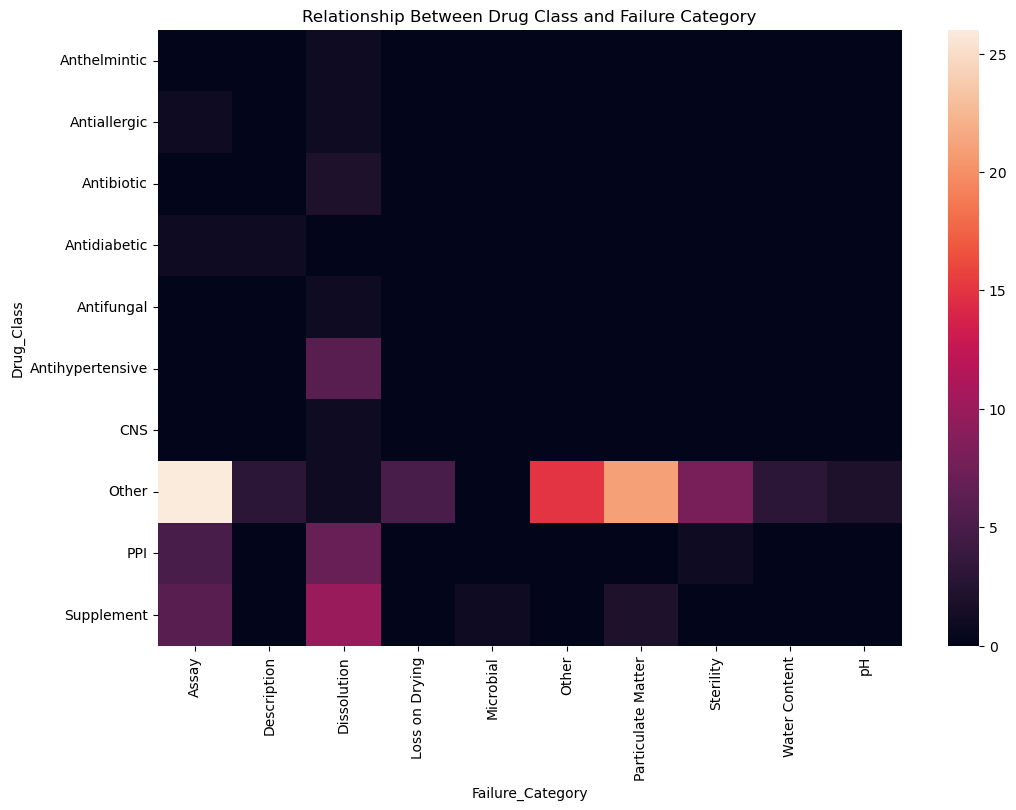

In [210]:
plt.figure(figsize=(12,8))
sns.heatmap(pd.crosstab(master_df["Drug_Class"],master_df["Failure_Category"]))
plt.title("Relationship Between Drug Class and Failure Category")
plt.show()

## Dissolution Failure Analysis

### Dissolution failures are particularly important because they directly influence drug release and bioavailability.

### This section investigates which Medicine types and therapeutic classes are most commonly associated with dissolution-related NSQ observations.

In [190]:
dissolution_df["Medicine_type"].value_counts()

Medicine_type
Tablet     26
Capsule     4
Name: count, dtype: int64

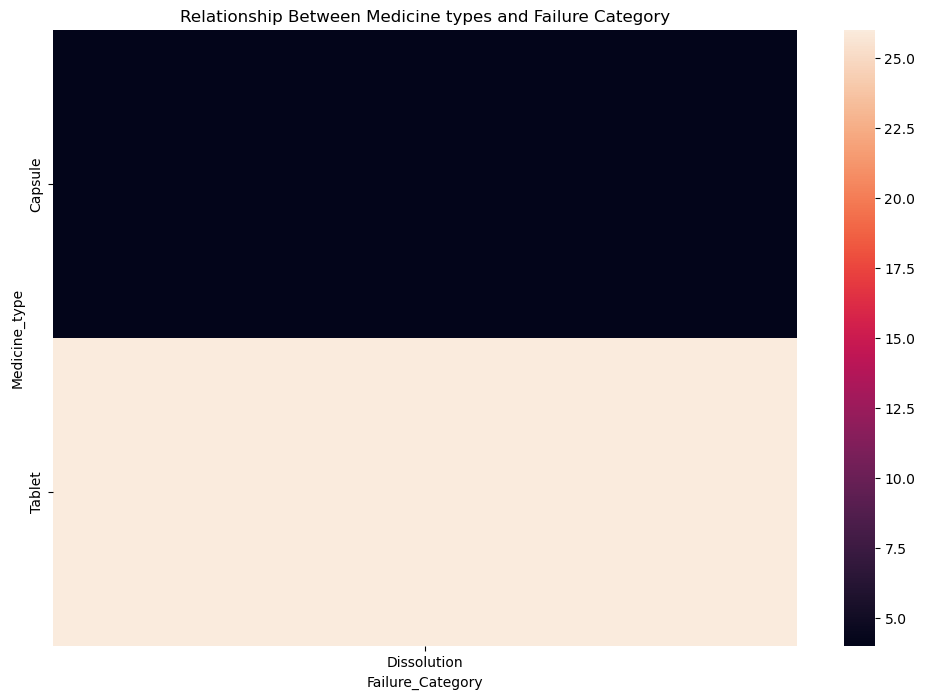

In [211]:
plt.figure(figsize=(12,8))
sns.heatmap(pd.crosstab(dissolution_df["Medicine_type"],dissolution_df["Failure_Category"]))
plt.title("Relationship Between Medicine types and Failure Category")
plt.show()

## Finding 

### Dissolution failures were concentrated among oral solid dosage forms and were observed repeatedly in selected therapeutic categories including PPIs, supplements and antihypertensive formulations.

In [200]:
top15_manu=master_df["Manufactured By"].value_counts().head(15)

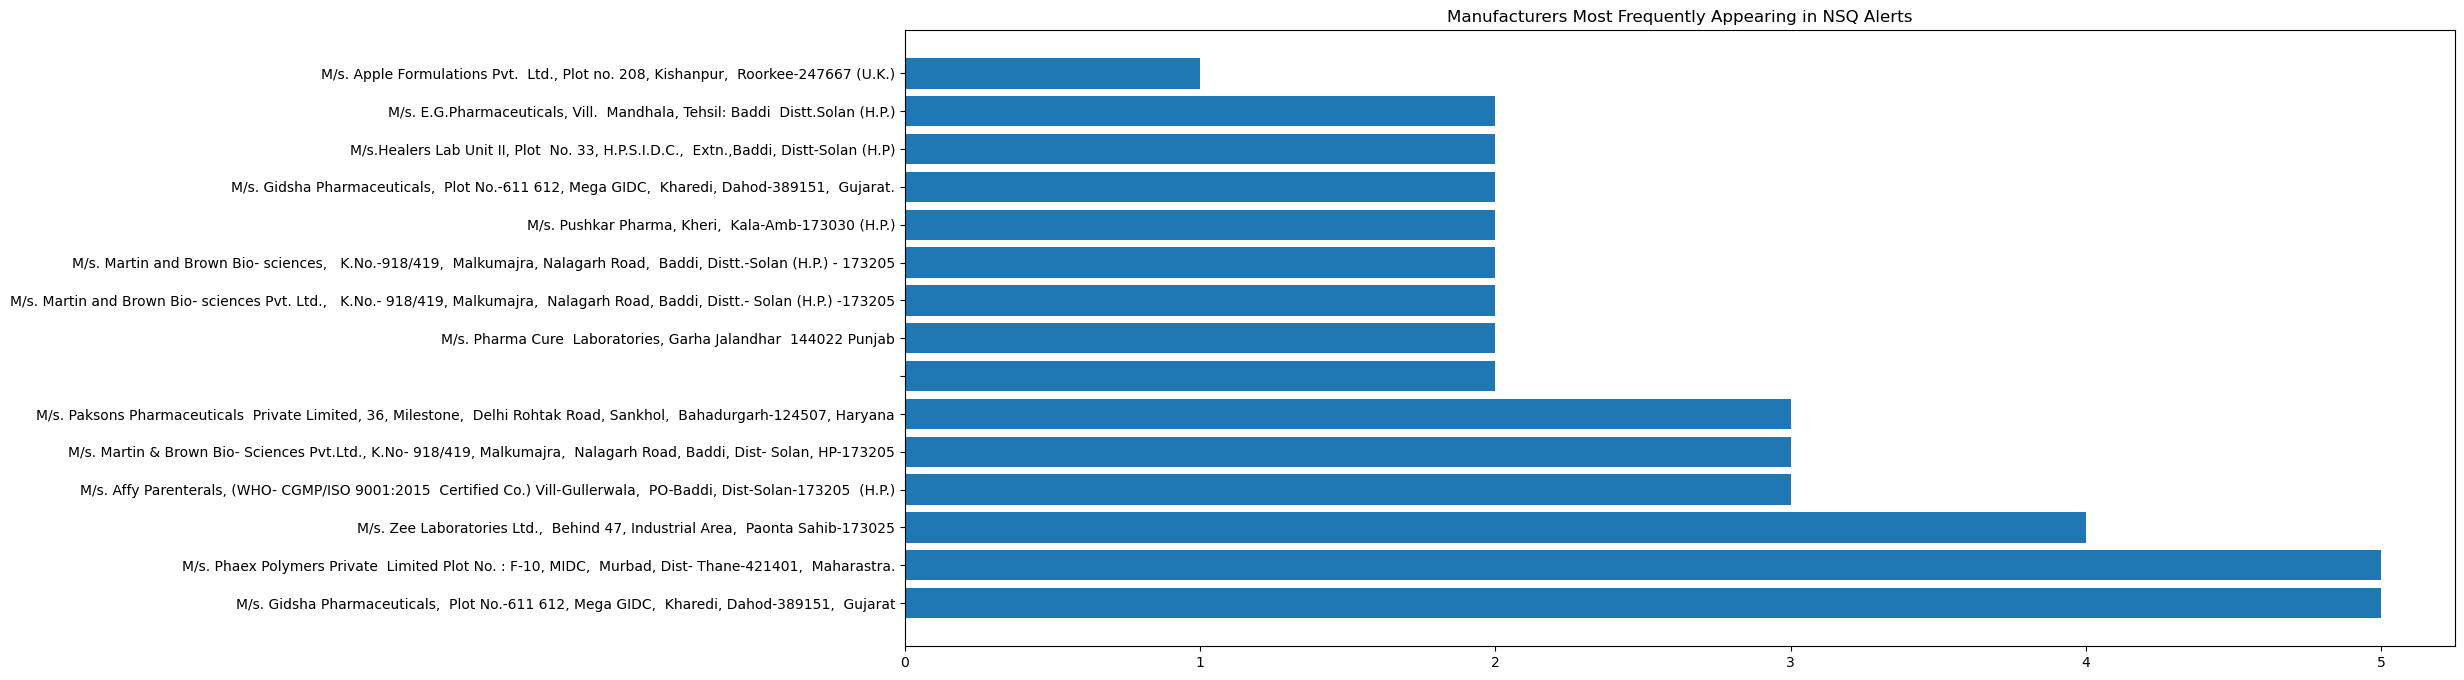

In [212]:
plt.figure(figsize=(20,8))
plt.barh(top15_manu.index,top15_manu.values)
plt.title("Manufacturers Most Frequently Appearing in NSQ Alerts")
plt.show()

### Certain manufacturer's names came up multiple times in the NSQ alerts

## Conclusions

### 1. Assay and Dissolution represented the most common NSQ failure categories.

### 2. Dissolution failures were predominantly associated with oral solid dosage forms.

### 3. Certain therapeutic classes appeared repeatedly within dissolution-related alerts.

### 4. The observed trends provide a foundation for future NSQ risk prediction systems based on formulation characteristics and quality-failure history.